Loading the necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Importing the dataset

In [2]:
df = pd.read_csv('../data/credit_risk_dataset.csv')
df.head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


Analyzing the data

In [3]:
print(df.shape)
df.info()

df.describe().T

(32581, 12)
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


Notice obvious mistakes producing outliers in age and empoyment length colums. The maximum age is 144 and the maximum employemnt legth is 123

Cheking for missing data and duplicates

In [4]:
print(df.nunique())
df.isnull().sum()


person_age                      58
person_income                 4295
person_home_ownership            4
person_emp_length               36
loan_intent                      6
loan_grade                       7
loan_amnt                      753
loan_int_rate                  348
loan_status                      2
loan_percent_income             77
cb_person_default_on_file        2
cb_person_cred_hist_length      29
dtype: int64


person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [5]:
for col in df:
    print(col)
    print(df[col].unique())

person_age
[ 22  21  25  23  24  26 144 123  20  32  34  29  33  28  35  31  27  30
  36  40  50  45  37  39  44  43  41  46  38  47  42  48  49  58  65  51
  53  66  61  54  57  59  62  60  55  52  64  70  78  69  56  73  63  94
  80  84  76  67]
person_income
[  59000    9600   65500 ...  720000 1900000    4888]
person_home_ownership
<StringArray>
['RENT', 'OWN', 'MORTGAGE', 'OTHER']
Length: 4, dtype: str
person_emp_length
[123.   5.   1.   4.   8.   2.   6.   7.   0.   9.   3.  10.  nan  11.
  18.  12.  17.  14.  16.  13.  19.  15.  20.  22.  21.  24.  23.  26.
  25.  27.  28.  31.  41.  34.  29.  38.  30.]
loan_intent
<StringArray>
[         'PERSONAL',         'EDUCATION',           'MEDICAL',
           'VENTURE',   'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
Length: 6, dtype: str
loan_grade
<StringArray>
['D', 'B', 'C', 'A', 'E', 'F', 'G']
Length: 7, dtype: str
loan_amnt
[35000  1000  5500  2500  1600  4500 30000  1750 34800 34000  1500 33950
 33000  4575  1400 32500  4000  2000 320

Univariate analysis

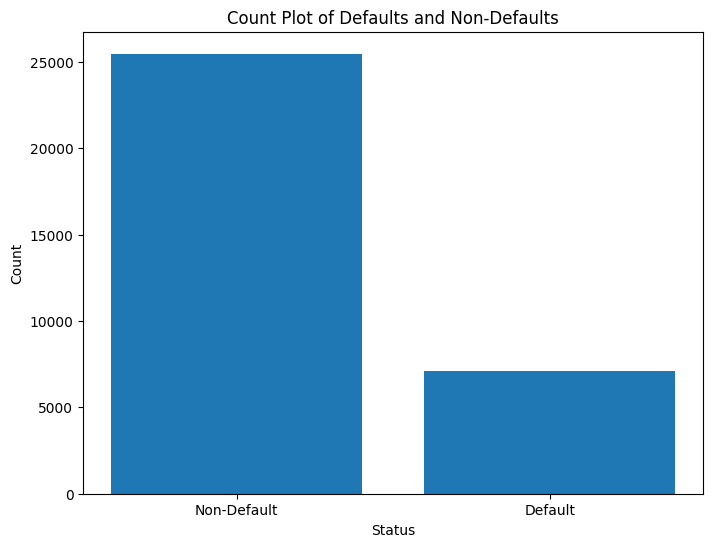

In [6]:
loan_status_counts = df['loan_status'].value_counts()

plt.figure(figsize=(8,6))
plt.bar(loan_status_counts.index, loan_status_counts)
plt.xticks([0,1], ['Non-Default', 'Default'])
plt.title('Count Plot of Defaults and Non-Defaults')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

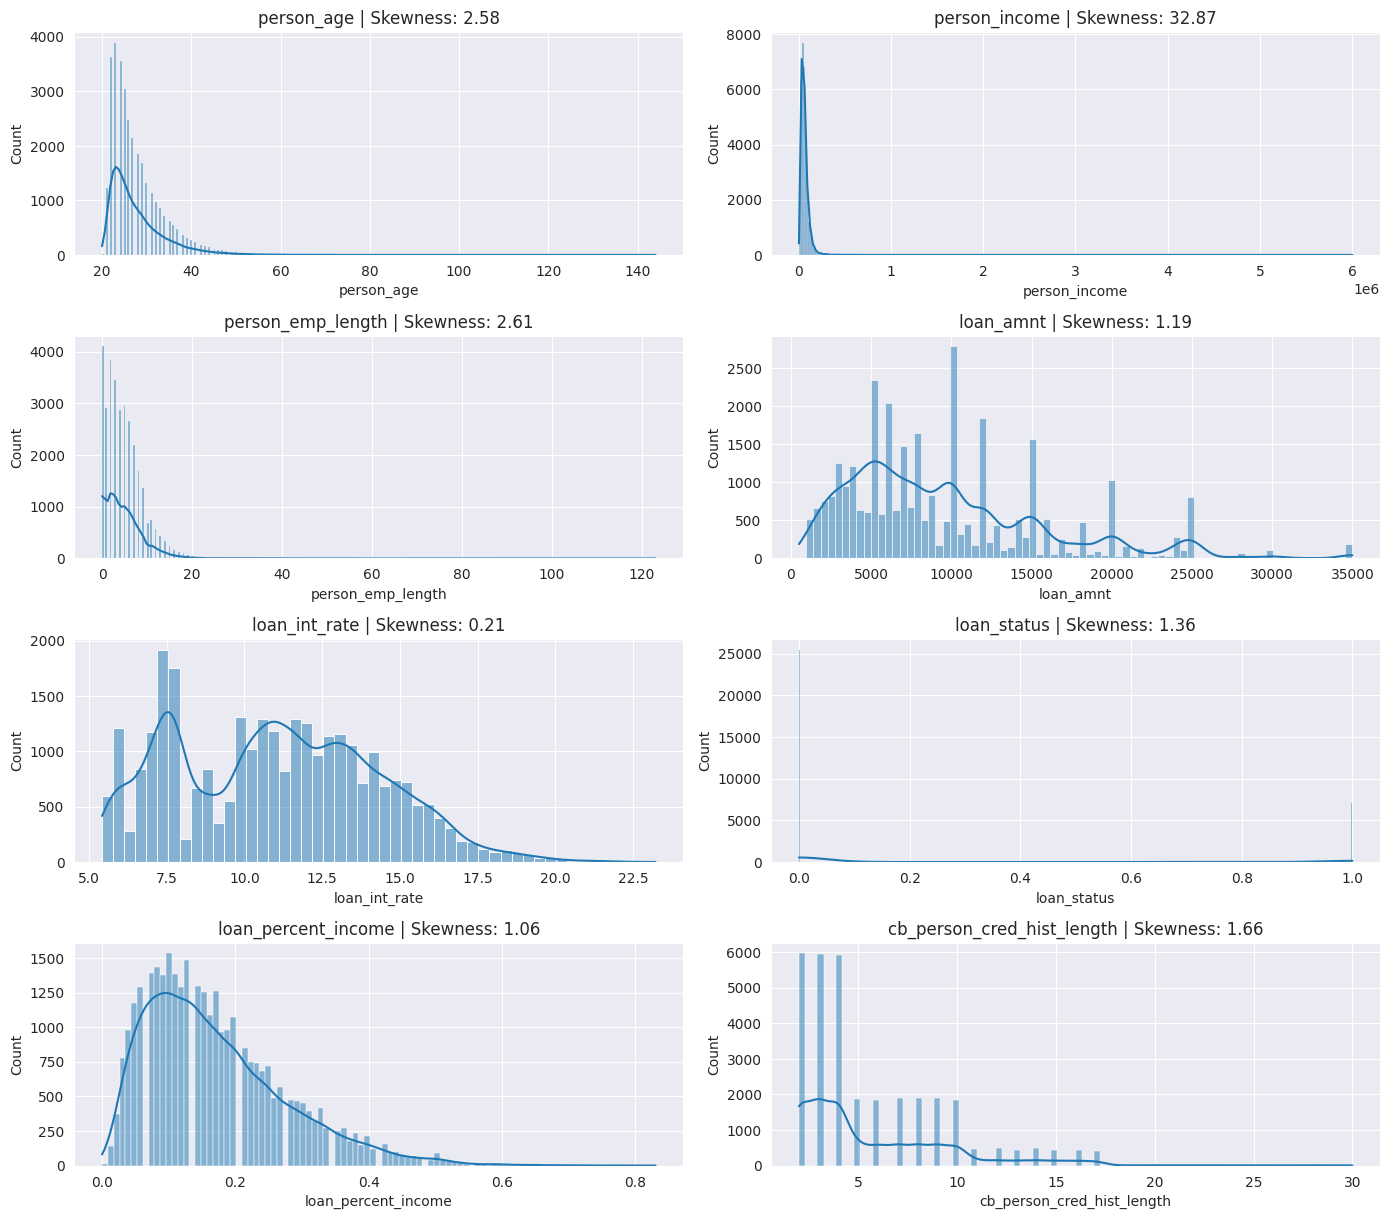

In [7]:
sns.set_style('darkgrid')

numerical_colums = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(14, len(numerical_colums) * 3))
for idx, feature in enumerate(numerical_colums, 1):
    plt.subplot(len(numerical_colums), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {df[feature].skew():.2f}")

plt.tight_layout()
plt.show()

Bivariate Analysis

<Figure size 1000x600 with 0 Axes>

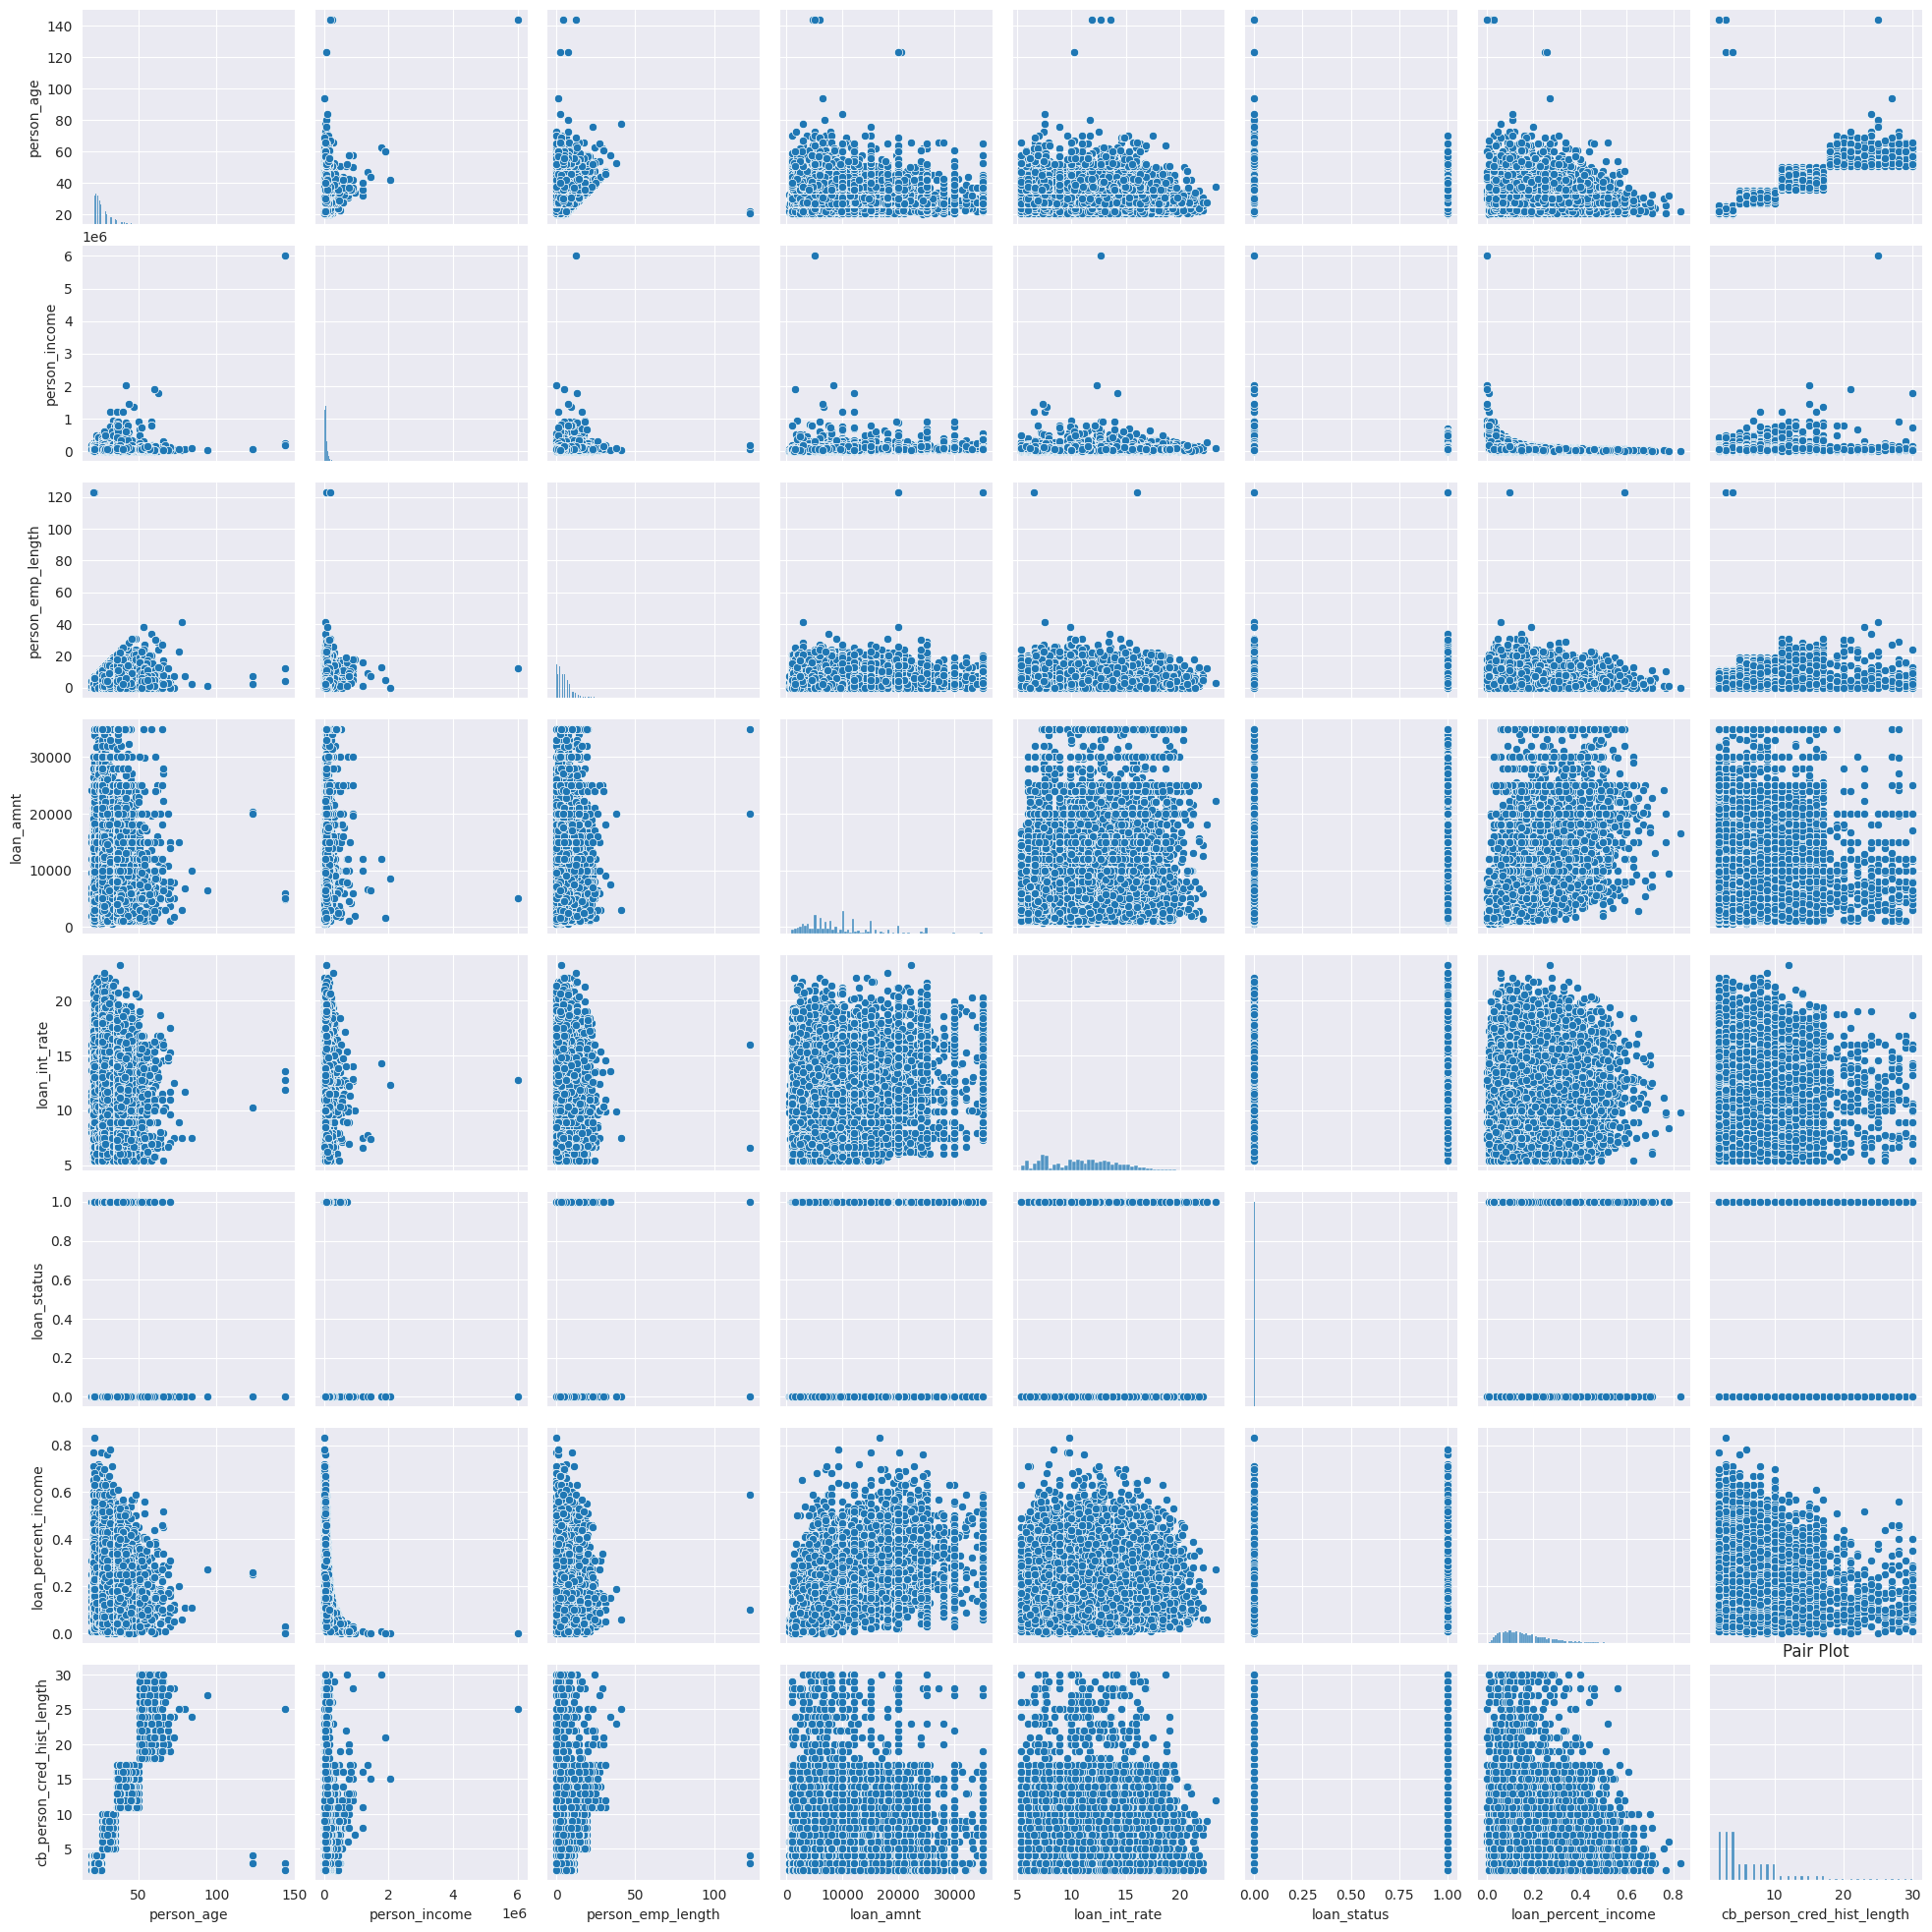

In [8]:
plt.figure(figsize=(10,6))

sns.pairplot(df)

plt.title('Pair Plot')
plt.show()

Correlation Matrix

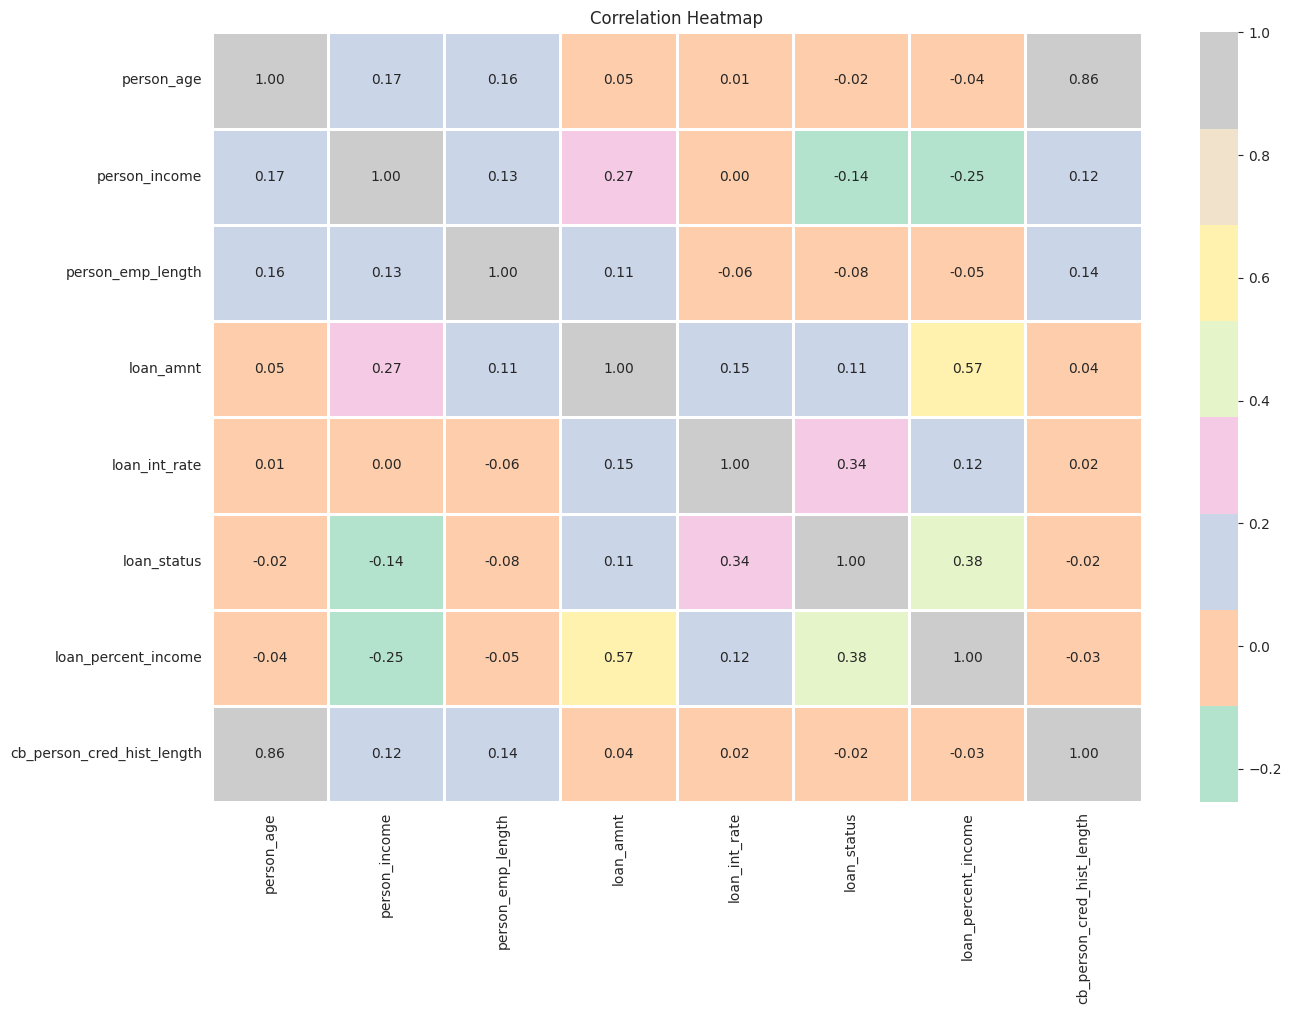

In [9]:
plt.figure(figsize=(15, 10))

sns.heatmap(df[numerical_colums].corr(), annot=True, fmt='.2f', cmap='Pastel2', linewidths=2)

plt.title('Correlation Heatmap')
plt.show()

Further exploring the relationship between loan status, loan interest rate and loan as a perentage of income because of substantial correlation

<Axes: xlabel='loan_status', ylabel='loan_int_rate'>

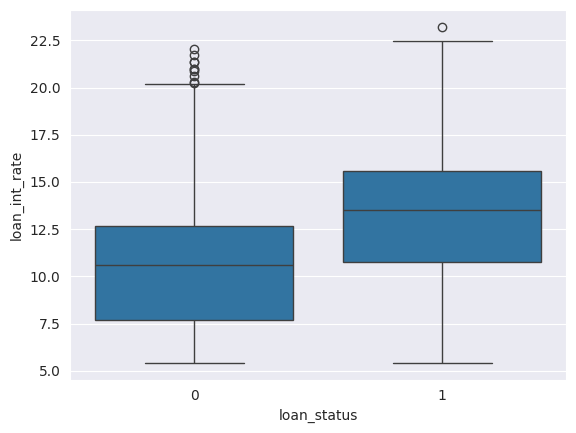

In [10]:
sns.boxplot(x='loan_status', y='loan_int_rate', data=df)

<Axes: xlabel='loan_status', ylabel='loan_percent_income'>

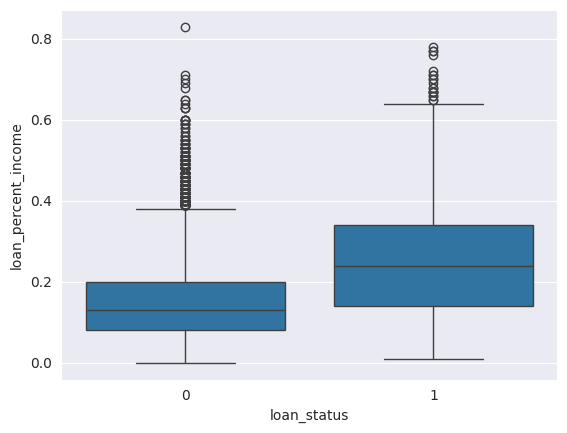

In [11]:
sns.boxplot(x='loan_status', y='loan_percent_income', data=df)